In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2pvbmF0aGFuL0RvY3VtZW50cy9VbkJvc3F1ZS9NYXN0ZXJFQUNEL0N1cnNvcy9NYWNoaW5lTGVhcm5pbmdJL01hY2hpbmVMZWFybmluZ0Jvb2s='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/importlib/_bootstrap.py": 1746004236.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/importlib/_bootstrap_external.py": 1746004236.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/codecs.py": 1746004221.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/aliases.py": 1746004240.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/cp437.py": 1746004241.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/__init__.py": 1746004240.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/utf_8.py": 1746004242.0, "/Library/Developer/CommandLineT

In [2]:
#| label: load-mnist

from sklearn.datasets import fetch_openml

mnist = fetch_openml(
    "mnist_784",
    as_frame=False,
    parser="auto"
)

In [3]:
#| label: inspect-mnist

mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [4]:
#| label: extract-features-target

X, y = mnist.data, mnist.target

print("Feature matrix:", X.shape)
print("Target vector:", y.shape)

Feature matrix: (70000, 784)
Target vector: (70000,)


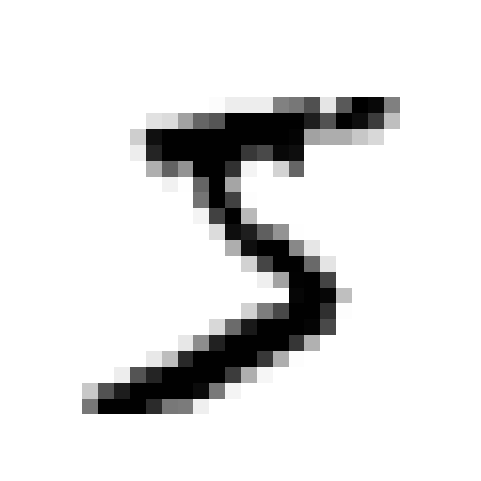

In [5]:
#| label: fig-first-mnist-digit
#| fig-cap: First handwritten digit in the MNIST dataset.
#| fig-align: center

import matplotlib.pyplot as plt

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.figure(figsize=(3, 3))
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [6]:
y[0]

'5'

In [7]:
#| label: convert-target

import numpy as np

y = y.astype(np.uint8)

print("Target type:", y.dtype)
print("First labels:", y[:10])

Target type: uint8
First labels: [5 0 4 1 9 2 1 3 1 4]


In [8]:
#| label: split-mnist

X_train, X_test = X[:60_000], X[60_000:]
y_train, y_test = y[:60_000], y[60_000:]

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (60000, 784)
Test set: (10000, 784)


In [9]:
#| label: binary-target

y_train_5 = y_train == 5
y_test_5 = y_test == 5

print("Number of 5s in training:", y_train_5.sum())
print("Proportion of 5s:", y_train_5.mean())

Number of 5s in training: 5421
Proportion of 5s: 0.09035


In [10]:
#| label: train-sgd-binary

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [11]:
#| label: first-binary-prediction

prediction = sgd_clf.predict([some_digit])

print("Predicted as 5:", prediction[0])
print("Actually a 5:", y[0] == 5)

Predicted as 5: True
Actually a 5: True


In [12]:
#| label: manual-cross-validation
#| code-fold: true

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

skfolds = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

for fold, (train_index, valid_index) in enumerate(
    skfolds.split(X_train, y_train_5),
    start=1
):
    clone_clf = clone(sgd_clf)

    X_train_fold = X_train[train_index]
    y_train_fold = y_train_5[train_index]
    X_valid_fold = X_train[valid_index]
    y_valid_fold = y_train_5[valid_index]

    clone_clf.fit(X_train_fold, y_train_fold)
    y_valid_pred = clone_clf.predict(X_valid_fold)

    accuracy = (y_valid_pred == y_valid_fold).mean()
    print(f"Fold {fold} accuracy: {accuracy:.4f}")

/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Fold 1 accuracy: 0.9669


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Fold 2 accuracy: 0.9163


Fold 3 accuracy: 0.9678


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [13]:
#| label: binary-cross-validation

from sklearn.model_selection import cross_val_score

accuracy_scores = cross_val_score(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)

print("Fold accuracies:", accuracy_scores)
print("Mean accuracy:", accuracy_scores.mean())

/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Fold accuracies: [0.95035 0.96035 0.9604 ]
Mean accuracy: 0.9570333333333334


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [14]:
#| label: never-five-classifier

from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    """Classifier that always predicts the negative class."""

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        return np.zeros(shape=(len(X),), dtype=bool)

In [15]:
#| label: evaluate-never-five

never_5_clf = Never5Classifier()

baseline_scores = cross_val_score(
    never_5_clf,
    X_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)

print("Baseline accuracies:", baseline_scores)
print("Mean baseline accuracy:", baseline_scores.mean())

Baseline accuracies: [0.91125 0.90855 0.90915]
Mean baseline accuracy: 0.90965


In [16]:
#| label: cross-validated-predictions

from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3
)

/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [17]:
#| label: binary-confusion-matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [18]:
#| label: unpack-confusion-matrix

tn, fp, fn, tp = cm.ravel()

print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

True negatives: 53892
False positives: 687
False negatives: 1891
True positives: 3530


In [19]:
#| label: perfect-confusion-matrix

y_train_perfect_predictions = y_train_5

confusion_matrix(
    y_train_5,
    y_train_perfect_predictions
)

array([[54579,     0],
       [    0,  5421]])

In [20]:
#| label: precision-and-recall

from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_train_5, y_train_pred)
recall = recall_score(y_train_5, y_train_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.8371
Recall: 0.6512


In [21]:
#| label: manual-precision-recall

precision_manual = tp / (tp + fp)
recall_manual = tp / (tp + fn)

print(f"Manual precision: {precision_manual:.4f}")
print(f"Manual recall: {recall_manual:.4f}")

Manual precision: 0.8371
Manual recall: 0.6512


In [22]:
#| label: specificity

specificity = tn / (tn + fp)
print(f"Specificity: {specificity:.4f}")

Specificity: 0.9874


In [23]:
#| label: f1-score

from sklearn.metrics import f1_score

f1 = f1_score(y_train_5, y_train_pred)
print(f"F1-score: {f1:.4f}")

F1-score: 0.7325


In [24]:
#| label: decision-score

y_score_some_digit = sgd_clf.decision_function([some_digit])

print("Decision score:", y_score_some_digit[0])
print("Default prediction:", y_score_some_digit[0] >= 0)

Decision score: 2164.220302392576
Default prediction: True


In [25]:
#| label: compare-thresholds

for threshold in [0, 2_000, 5_000, 8_000]:
    prediction = y_score_some_digit[0] >= threshold
    print(f"Threshold {threshold:>5}: predicted as 5 = {prediction}")

Threshold     0: predicted as 5 = True
Threshold  2000: predicted as 5 = True
Threshold  5000: predicted as 5 = False
Threshold  8000: predicted as 5 = False


In [26]:
#| label: cross-validated-decision-scores

y_scores = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    method="decision_function"
)

/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [27]:
#| label: compute-pr-curve

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_train_5,
    y_scores
)

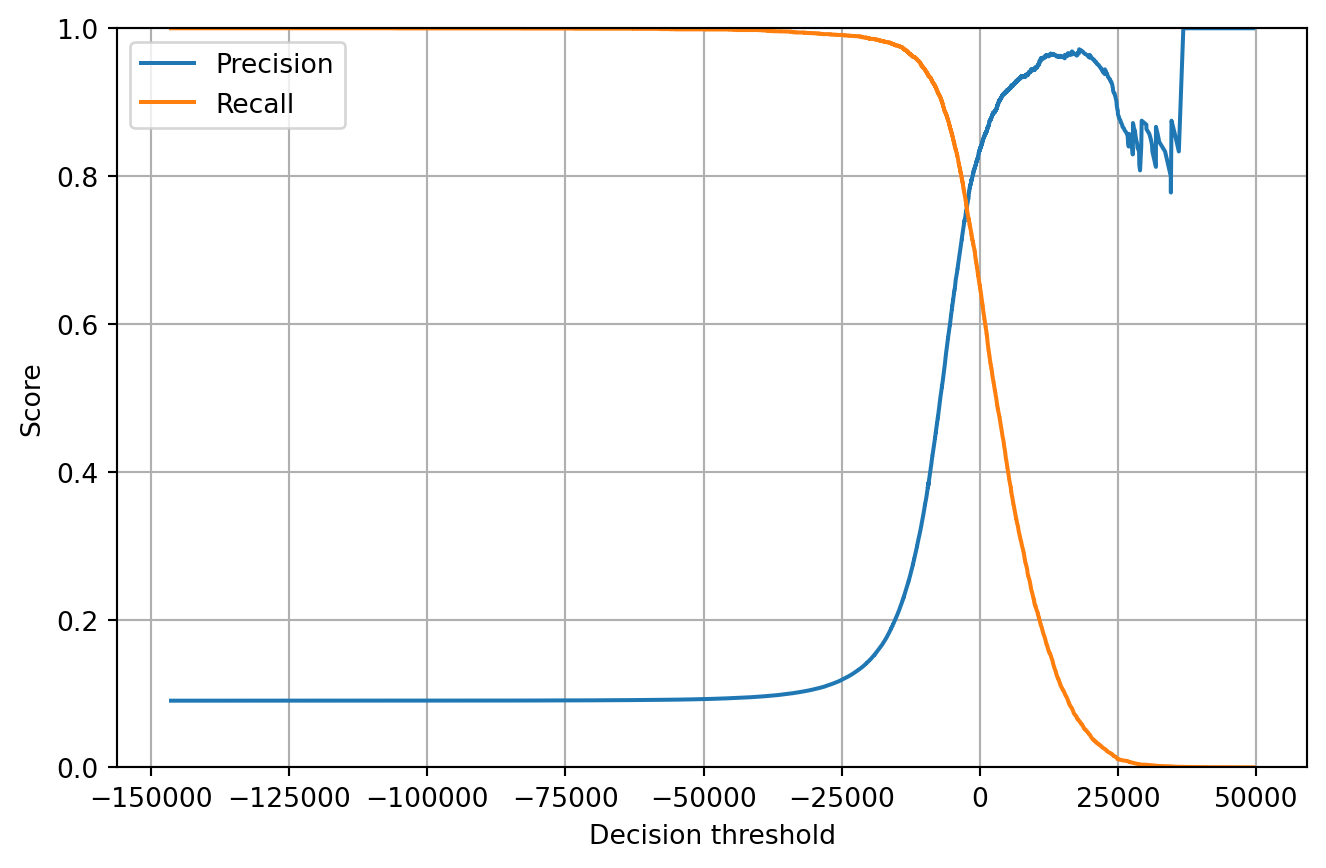

In [28]:
#| label: fig-precision-recall-threshold
#| fig-cap: Precision and recall as functions of the decision threshold.
#| fig-align: center

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

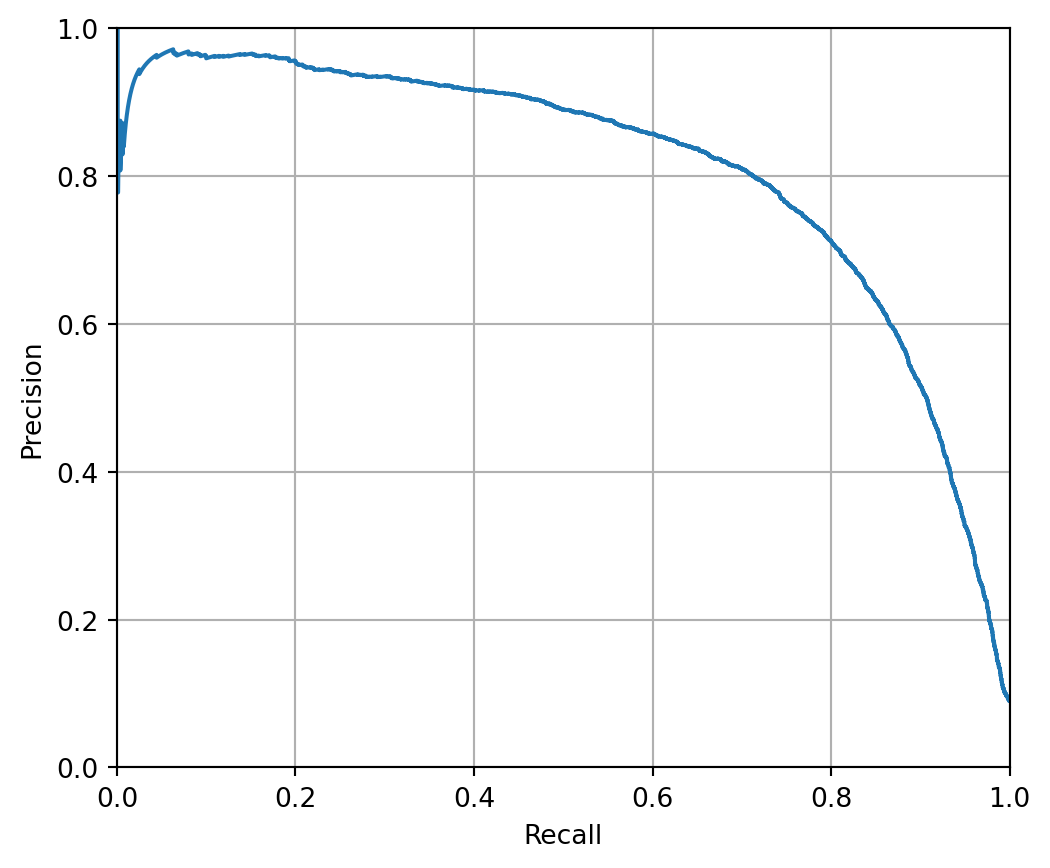

In [29]:
#| label: fig-precision-recall-curve
#| fig-cap: Precision–recall curve for the binary SGD classifier.
#| fig-align: center

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

In [30]:
#| label: threshold-for-precision

target_precision = 0.90
threshold_index = np.argmax(precisions >= target_precision)
threshold_90_precision = thresholds[threshold_index]

print("Threshold for at least 90% precision:", threshold_90_precision)

Threshold for at least 90% precision: 3370.019499144185


In [31]:
#| label: evaluate-selected-threshold

y_train_pred_90 = y_scores >= threshold_90_precision

precision_90 = precision_score(y_train_5, y_train_pred_90)
recall_90 = recall_score(y_train_5, y_train_pred_90)

print(f"Precision: {precision_90:.4f}")
print(f"Recall: {recall_90:.4f}")

Precision: 0.9000
Recall: 0.4800


In [32]:
#| label: compute-roc

from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(
    y_train_5,
    y_scores
)

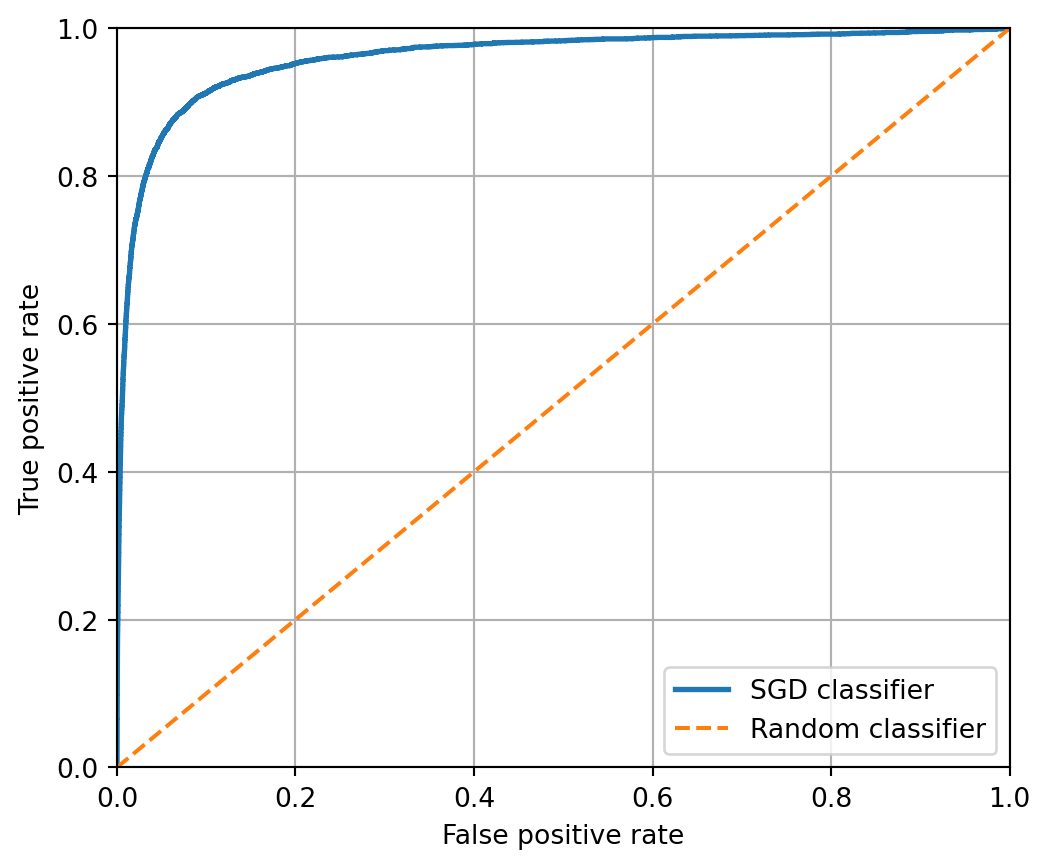

In [33]:
#| label: fig-roc-sgd
#| fig-cap: ROC curve for the binary SGD classifier.
#| fig-align: center

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label="SGD classifier")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

In [34]:
#| label: roc-auc-sgd

from sklearn.metrics import roc_auc_score

sgd_roc_auc = roc_auc_score(y_train_5, y_scores)
print(f"SGD ROC AUC: {sgd_roc_auc:.4f}")

SGD ROC AUC: 0.9605


In [35]:
#| label: random-forest-probabilities
#| code-fold: true

from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

y_probas_forest = cross_val_predict(
    forest_clf,
    X_train,
    y_train_5,
    cv=3,
    method="predict_proba",
    n_jobs=-1
)

y_scores_forest = y_probas_forest[:, 1]

In [36]:
#| label: compare-roc-classifiers

fpr_forest, tpr_forest, _ = roc_curve(
    y_train_5,
    y_scores_forest
)

forest_roc_auc = roc_auc_score(
    y_train_5,
    y_scores_forest
)

print(f"SGD ROC AUC: {sgd_roc_auc:.4f}")
print(f"Random forest ROC AUC: {forest_roc_auc:.4f}")

SGD ROC AUC: 0.9605
Random forest ROC AUC: 0.9983


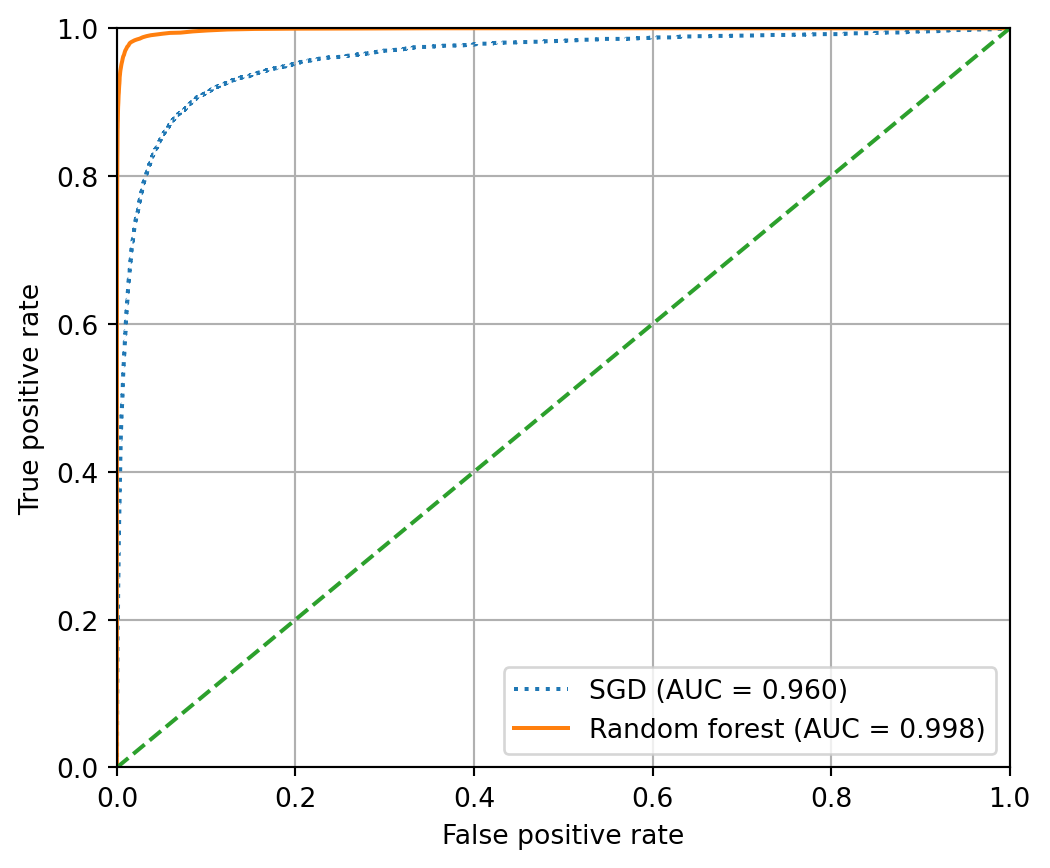

In [37]:
#| label: fig-roc-comparison
#| fig-cap: ROC curves for the SGD classifier and random forest.
#| fig-align: center

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linestyle=":", label=f"SGD (AUC = {sgd_roc_auc:.3f})")
plt.plot(
    fpr_forest,
    tpr_forest,
    label=f"Random forest (AUC = {forest_roc_auc:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

In [38]:
#| label: train-multiclass-svc
#| code-fold: true

from sklearn.svm import SVC

svc_training_size = 10_000

svm_clf = SVC()
svm_clf.fit(
    X_train[:svc_training_size],
    y_train[:svc_training_size]
)

svm_prediction = svm_clf.predict([some_digit])
print("SVC prediction:", svm_prediction[0])

SVC prediction: 5


In [39]:
#| label: svc-decision-scores

some_digit_scores = svm_clf.decision_function([some_digit])
predicted_index = np.argmax(some_digit_scores)

print("Decision scores:", some_digit_scores)
print("Predicted class:", svm_clf.classes_[predicted_index])

Decision scores: [[ 0.73640179  3.74695649  6.22503198  8.30364879 -0.30459674  9.30612304
   1.73376956  3.76312093  7.22128341  3.7959883 ]]
Predicted class: 5


In [40]:
#| label: explicit-ovr
#| code-fold: true

from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC())
ovr_clf.fit(
    X_train[:svc_training_size],
    y_train[:svc_training_size]
)

print("OvR prediction:", ovr_clf.predict([some_digit])[0])
print("Number of binary estimators:", len(ovr_clf.estimators_))

OvR prediction: 5
Number of binary estimators: 10


In [41]:
#| label: train-multiclass-sgd

multiclass_sgd = SGDClassifier(random_state=42)
multiclass_sgd.fit(X_train, y_train)

print("Prediction:", multiclass_sgd.predict([some_digit])[0])
print(
    "Scores:",
    multiclass_sgd.decision_function([some_digit])
)

Prediction: 3
Scores: [[-31893.03095419 -34419.69069632  -9530.63950739   1823.73154031
  -22320.14822878  -1385.80478895 -26188.91070951 -16147.51323997
   -4604.35491274 -12050.767298  ]]


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [42]:
#| label: multiclass-sgd-cv

multiclass_accuracy = cross_val_score(
    multiclass_sgd,
    X_train,
    y_train,
    cv=3,
    scoring="accuracy"
)

print("Fold accuracies:", multiclass_accuracy)
print("Mean accuracy:", multiclass_accuracy.mean())

/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Fold accuracies: [0.87365 0.85835 0.8689 ]
Mean accuracy: 0.8669666666666668


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [43]:
#| label: scaled-multiclass-pipeline

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

scaled_sgd_clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(random_state=42)
)

scaled_accuracy = cross_val_score(
    scaled_sgd_clf,
    X_train,
    y_train,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

print("Scaled fold accuracies:", scaled_accuracy)
print("Scaled mean accuracy:", scaled_accuracy.mean())

/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Scaled fold accuracies: [0.89165 0.89205 0.90055]
Scaled mean accuracy: 0.89475


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [44]:
#| label: multiclass-cross-validated-predictions
#| code-fold: true

y_train_pred_multiclass = cross_val_predict(
    scaled_sgd_clf,
    X_train,
    y_train,
    cv=3,
    n_jobs=-1
)

/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


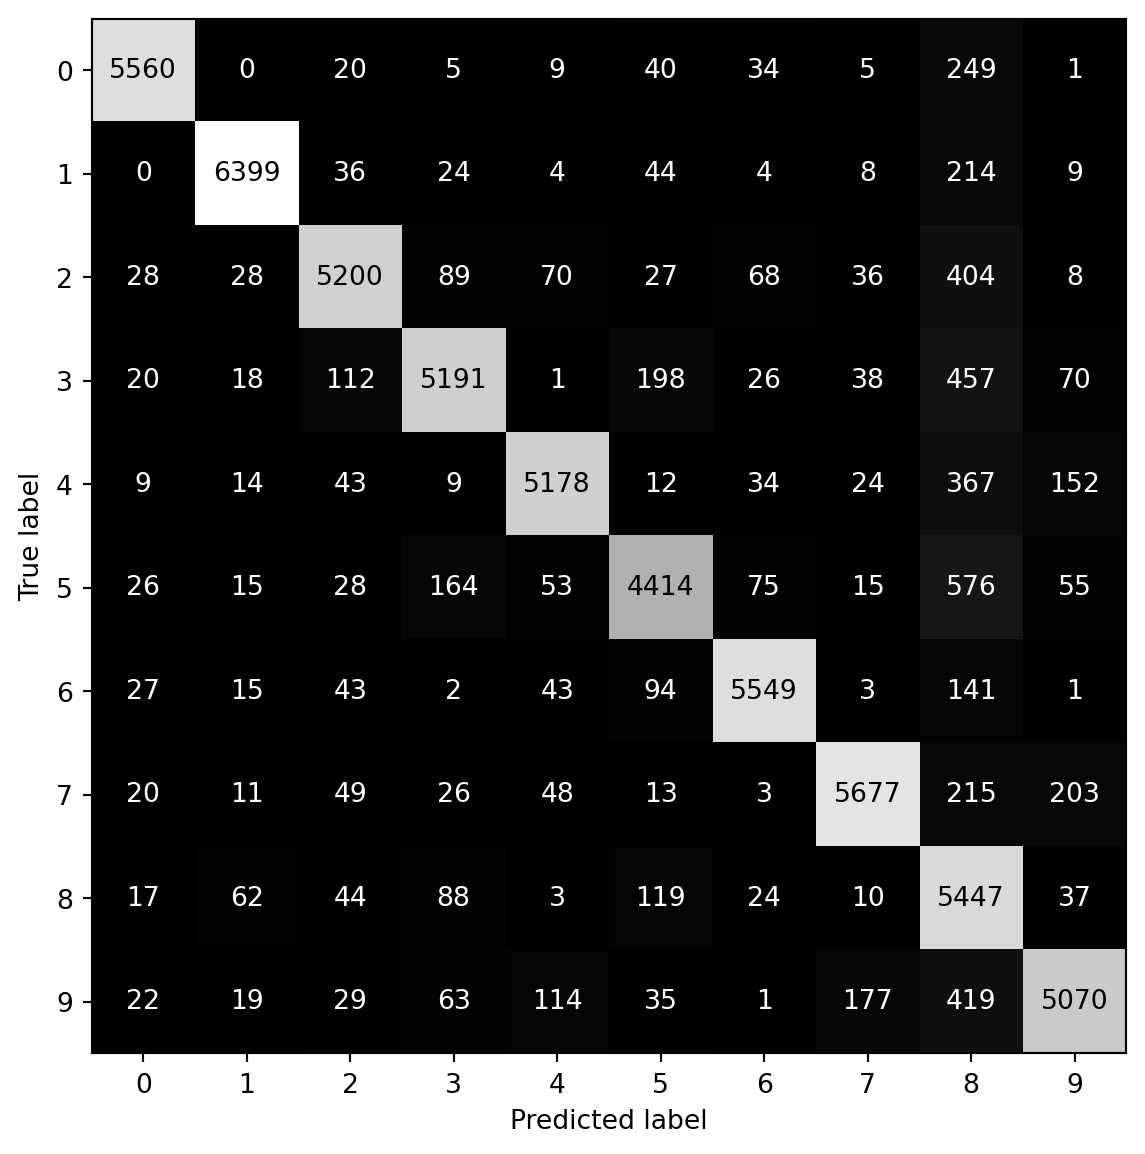

In [45]:
#| label: fig-multiclass-confusion-matrix
#| fig-cap: Confusion matrix for the multiclass SGD classifier.
#| fig-align: center

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred_multiclass,
    cmap="gray",
    ax=ax,
    colorbar=False
)

plt.show()

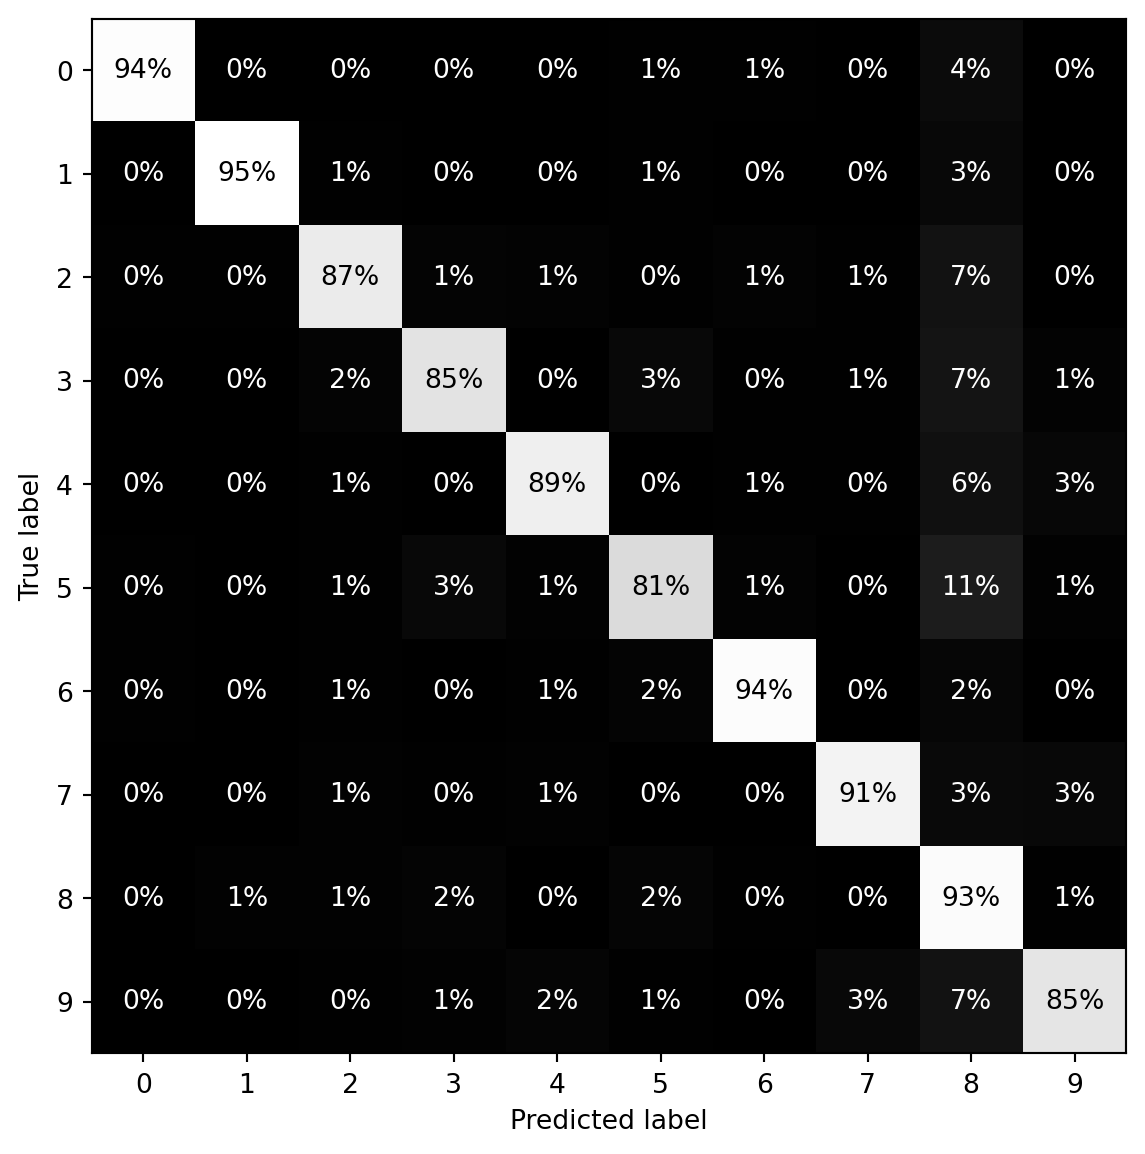

In [46]:
#| label: fig-normalized-confusion-matrix
#| fig-cap: Row-normalized confusion matrix. Each row represents the distribution of predictions for one true class.
#| fig-align: center

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred_multiclass,
    normalize="true",
    values_format=".0%",
    cmap="gray",
    ax=ax,
    colorbar=False
)

plt.show()

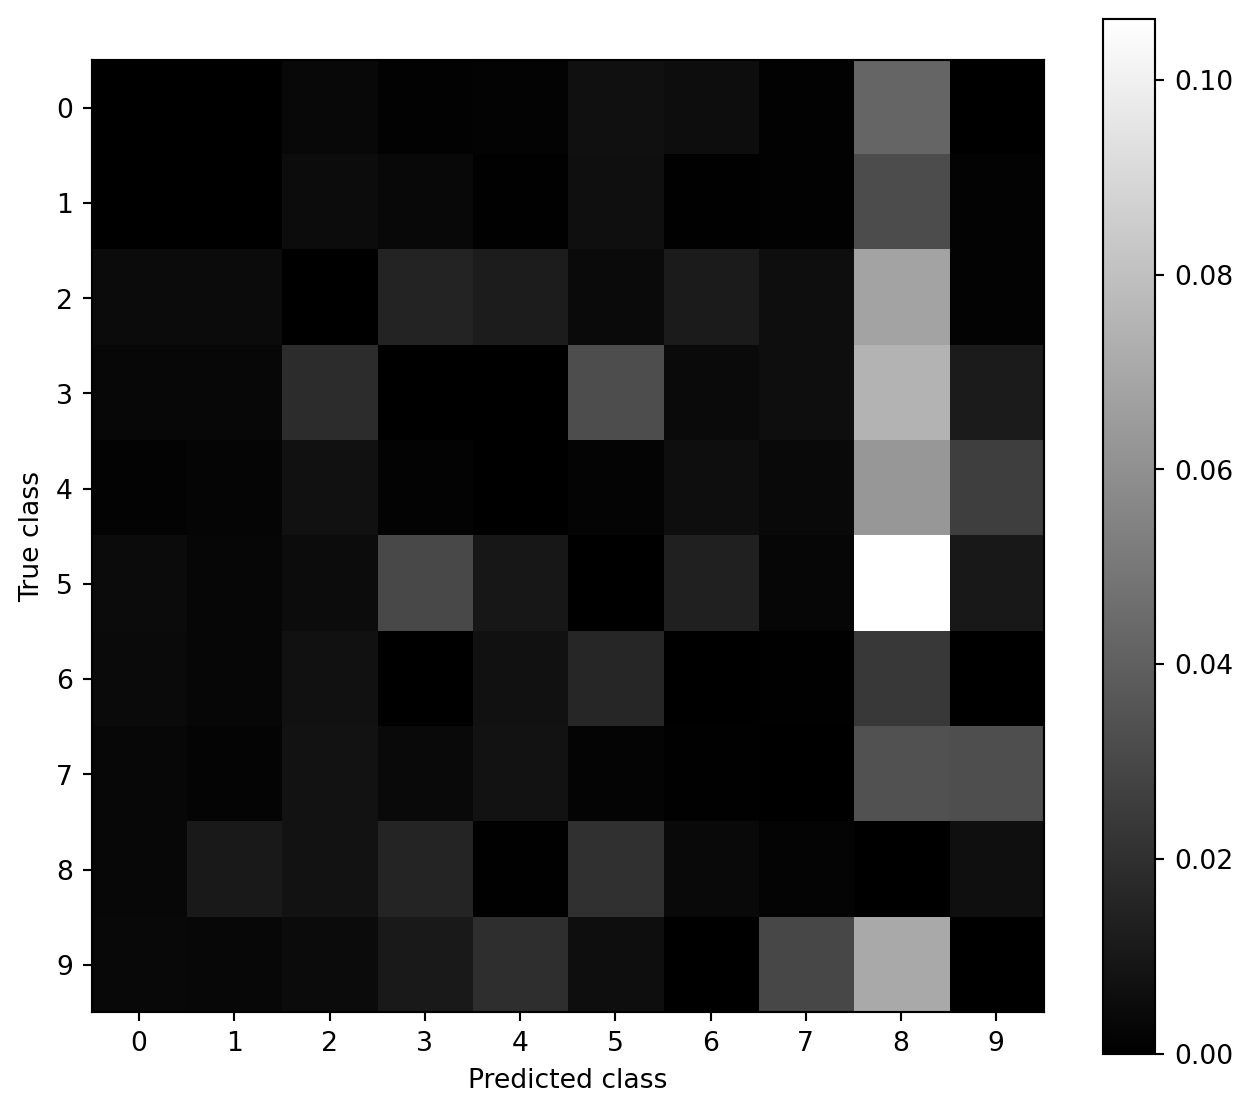

In [47]:
#| label: fig-normalized-error-matrix
#| fig-cap: Normalized multiclass errors after removing the diagonal.
#| fig-align: center

multiclass_cm = confusion_matrix(
    y_train,
    y_train_pred_multiclass,
    normalize="true"
)

np.fill_diagonal(multiclass_cm, 0)

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(multiclass_cm, cmap="gray")

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticks(range(10))
ax.set_yticks(range(10))

fig.colorbar(image, ax=ax)
plt.show()

In [48]:
#| label: multiclass-classification-report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_train,
        y_train_pred_multiclass,
        digits=3
    )
)

              precision    recall  f1-score   support

           0      0.971     0.939     0.954      5923
           1      0.972     0.949     0.961      6742
           2      0.928     0.873     0.899      5958
           3      0.917     0.847     0.880      6131
           4      0.938     0.886     0.911      5842
           5      0.884     0.814     0.847      5421
           6      0.954     0.938     0.946      5918
           7      0.947     0.906     0.926      6265
           8      0.642     0.931     0.760      5851
           9      0.904     0.852     0.878      5949

    accuracy                          0.895     60000
   macro avg      0.906     0.893     0.896     60000
weighted avg      0.907     0.895     0.898     60000



In [49]:
#| label: create-multilabel-target

y_train_large = y_train >= 7
y_train_odd = y_train % 2 == 1

y_multilabel = np.c_[
    y_train_large,
    y_train_odd
]

y_multilabel[:10]

array([[False,  True],
       [False, False],
       [False, False],
       [False,  True],
       [ True,  True],
       [False, False],
       [False,  True],
       [False,  True],
       [False,  True],
       [False, False]])

In [50]:
#| label: train-multilabel-knn
#| code-fold: true

from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

print(
    "Prediction [large, odd]:",
    knn_clf.predict([some_digit])[0]
)

Prediction [large, odd]: [False  True]


/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [51]:
#| label: create-noisy-mnist
#| code-fold: true

rng = np.random.default_rng(42)

noise_train = rng.integers(
    0,
    100,
    size=X_train.shape,
    dtype=np.uint8
)

noise_test = rng.integers(
    0,
    100,
    size=X_test.shape,
    dtype=np.uint8
)

X_train_noisy = np.clip(
    X_train + noise_train,
    0,
    255
)

X_test_noisy = np.clip(
    X_test + noise_test,
    0,
    255
)

y_train_clean = X_train
y_test_clean = X_test

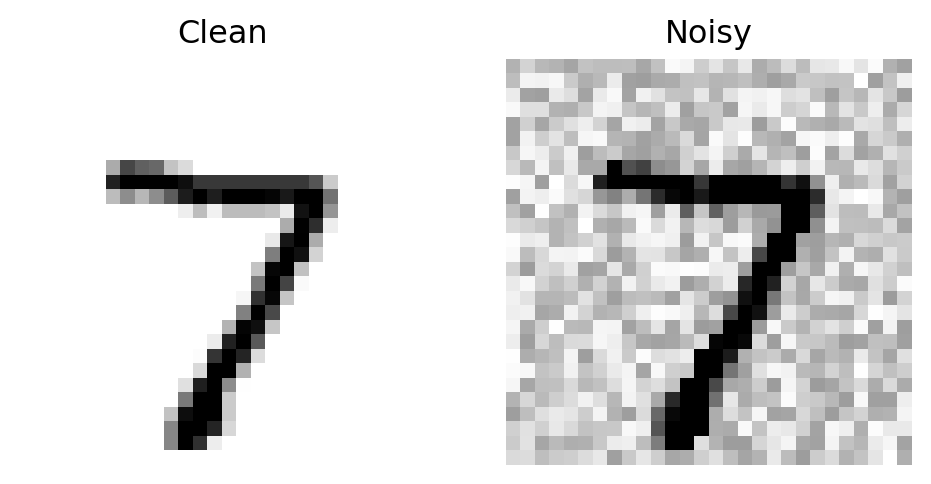

In [52]:
#| label: fig-noisy-mnist-example
#| fig-cap: Clean and noisy versions of an MNIST image.
#| fig-align: center

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(
    y_test_clean[0].reshape(28, 28),
    cmap="binary"
)
axes[0].set_title("Clean")
axes[0].axis("off")

axes[1].imshow(
    X_test_noisy[0].reshape(28, 28),
    cmap="binary"
)
axes[1].set_title("Noisy")
axes[1].axis("off")

plt.show()

In [53]:
#| label: train-multioutput-knn
#| code-fold: true
#| eval: false

denoising_training_size = 10_000

knn_denoiser = KNeighborsClassifier()
knn_denoiser.fit(
    X_train_noisy[:denoising_training_size],
    y_train_clean[:denoising_training_size]
)

clean_digit_prediction = knn_denoiser.predict(
    [X_test_noisy[0]]
)

In [54]:
#| label: fig-denoised-digit
#| fig-cap: Image reconstructed by the multioutput classifier.
#| fig-align: center
#| eval: false

plt.figure(figsize=(3, 3))
plt.imshow(
    clean_digit_prediction.reshape(28, 28),
    cmap="binary"
)
plt.axis("off")
plt.show()

In [55]:
#| label: final-binary-test-evaluation
#| eval: false

final_binary_clf = SGDClassifier(random_state=42)
final_binary_clf.fit(X_train, y_train_5)

y_test_pred = final_binary_clf.predict(X_test)

test_cm = confusion_matrix(y_test_5, y_test_pred)
test_precision = precision_score(y_test_5, y_test_pred)
test_recall = recall_score(y_test_5, y_test_pred)
test_f1 = f1_score(y_test_5, y_test_pred)

print("Test confusion matrix:")
print(test_cm)
print(f"Test precision: {test_precision:.4f}")
print(f"Test recall: {test_recall:.4f}")
print(f"Test F1-score: {test_f1:.4f}")